In [1]:
import os
from itertools import combinations
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, gaussian_kde
import pickle
from matplotlib import rcParams, cycler
from matplotlib.cm import ScalarMappable
import cmasher as cmr
import sys
sys.path.append(os.path.join('c:\\', *os.getcwd().split('\\')[1:-1]))
from sgcc11 import *

In [2]:
plt.rcParams['figure.dpi'] = 300
fontsize = 8
linewidth = 0.5

In [3]:
X = tf.convert_to_tensor([0.02,0.04,0.08,0.1,0.12,0.16,0.2,0.24,0.28,0.32], dtype = tf.float32)

In [4]:
v1_xs_file = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'project_datafiles', 'v1_ori_phase_condition_pcascores_wcomp.pkl')
v1_scores = pd.read_pickle(os.path.join('c:\\',*os.getcwd().split('\\')[1:-1], v1_xs_file))
#v1_scores = pd.read_pickle(os.path.join('/',*os.getcwd().split('/')[:-1], v1_xs_file))
v1_scores_condition_averaged = np.array([np.array(x) for x in v1_scores.scores.values]).mean(0)

In [5]:
Y_true = v1_scores_condition_averaged[:2,:,:].transpose(0,2,1)

In [6]:
# relaxed_param_bounds = {
#     "fts": [-200.0, 200.0],
#     "t": [1, 200.0],
#     "ampc": [0.01, 1.0],
#     'ampm': [-10.0, 10.0],
#     "ampg": [-10, 10.0],
#     "ampw": [0.0, 1.0],
#     "d": [0, 200.0],
#     "inh_d": [0, 100.0],
#     "inh_w": [-10.0, 10.0],
# }
param_bounds = {
    "fts": [0, 175],
    "t": [40, 125],
    "ampc": [0.01, 0.1],
    'ampm': [0,3],
    "ampg": [0.1, 4],
    "ampw": [0.01, 0.08],
    "d": [10, 40],
    "inh_d": [0, 40],
    "inh_w": [0, 3],
}

In [7]:
optimized_model_file = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'project_datafiles', 'permutation_test_free.pkl')
with open(optimized_model_file, 'rb') as f:
    optimized_model = pickle.load(f)

In [8]:
model = SGCCircuit(param_bounds, identify=False)

In [9]:
model.load_saved_parameters(optimized_model['final_epoch_params'])

In [10]:
loss_decay = optimized_model['loss_decay']
last_epoch = loss_decay[-1]
best = np.where(last_epoch == last_epoch.min())[0][0]
print(f"Index of best parameters: {best}, loss = {last_epoch[best]}")

Index of best parameters: 305, loss = 0.06591796875


In [11]:
predictions = model.predict(X)

In [12]:
v1_neuron_1, v1_neuron_2 = predictions[best]

In [13]:
low_sf_1 = v1_neuron_1[0]
high_sf_1 = v1_neuron_1[-1]

low_sf_2 = v1_neuron_2[0]
high_sf_2 = v1_neuron_2[-1]

In [14]:
x = np.arange(0.02,0.34,0.02)

In [15]:
def vector_len(a: np.ndarray): 
    # calculate the length of a vector by calculating the square root of its self dot product
    
    return np.sqrt(np.dot(a, a))

def vector_angle(a: np.ndarray, b: np.ndarray, output_type = 'radians'): 
    # calculate the angle between two vectors
    
    dotab = np.dot(a,b)
    lena = vector_len(a)
    lenb = vector_len(b)
    prodab = lena*lenb
    
    # theta is the arccosine of the dotproduct of a & b
    # over the product of the lengths of a & b
    theta = np.arccos(dotab/prodab)
    
    output = {
        'radians': theta,
        'degrees': np.degrees(theta)
    }
    
    if output_type not in list(output.keys()):
        print("Error: please specify an output type of either 'radians' or 'degrees'")
    
    return output[output_type]

ang = []
dotprod = []
for t in range(250):
    ang.append(
        vector_angle(
            [low_sf_1[t], low_sf_2[t]],
            [high_sf_1[t], high_sf_2[t]],
            output_type = 'degrees'
        )
    )

    dotprod.append(
        np.dot(
            [low_sf_1[t], low_sf_2[t]],
            [high_sf_1[t], high_sf_2[t]],
        )
    )

ang = np.array(ang)
dotprod = np.array(dotprod)

In [16]:
t0 = np.where(dotprod[50:] == dotprod[50:].max())[0][0] + 50
t1 = np.where(ang[t0:] == ang[t0:].max())[0][0] + t0

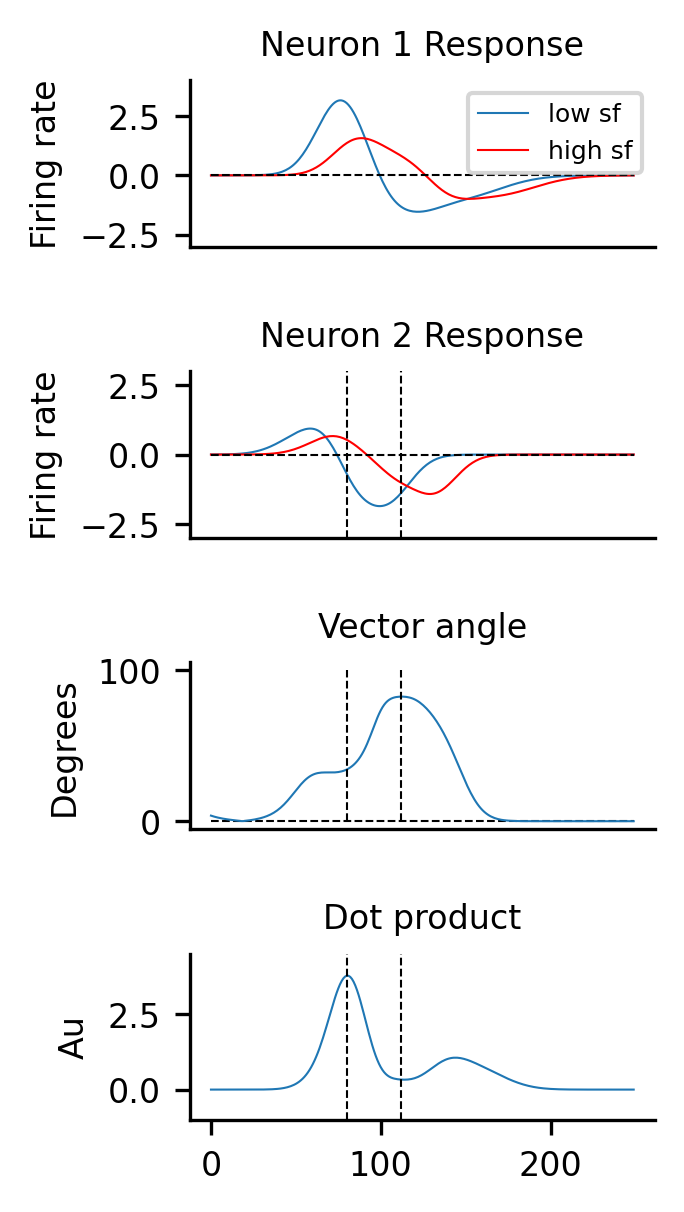

In [17]:
fig, ax = plt.subplots(4, figsize = (2,4.5))
ax[0].plot(low_sf_1, label = 'low sf', linewidth = linewidth)
ax[0].plot(high_sf_1, color = 'red', label = 'high sf', linewidth = linewidth)
# ax[0].plot([t0]*250, np.linspace(-3,4,250), '--', color = 'black', linewidth = linewidth)
# ax[0].plot([t1]*250, np.linspace(-3,4,250), '--', color = 'black', linewidth = linewidth)
ax[0].set_ylim(-3, 4)
ax[0].set_title("Neuron 1 Response", fontsize = fontsize)
ax[0].set_ylabel("Firing rate", fontsize = fontsize)
ax[0].legend(fontsize = 6)


ax[1].plot(low_sf_2, linewidth = linewidth)
ax[1].plot(high_sf_2, color = 'red', linewidth = linewidth)
ax[1].plot([t0]*250, np.linspace(-3,3,250), '--', color = 'black', linewidth = linewidth)
ax[1].plot([t1]*250, np.linspace(-3,3,250), '--', color = 'black', linewidth = linewidth)
ax[1].set_ylim(-3, 3)
ax[1].set_title("Neuron 2 Response", fontsize = fontsize)
ax[1].set_ylabel("Firing rate", fontsize = fontsize)

for i in range(4):
    ax[i].tick_params(labelsize = fontsize)
    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)

for i in range(3):
    ax[i].plot(np.zeros(250), '--', color = 'black', linewidth = linewidth)
    if i < 3:
        ax[i].set_xticks([])

ax[2].plot(ang, linewidth = linewidth)
ax[2].plot([t0]*250, np.linspace(0,100,250), '--', color = 'black', linewidth = linewidth)
ax[2].plot([t1]*250, np.linspace(0,100,250), '--', color = 'black', linewidth = linewidth)
#ax[2].set_ylim(0, 100)
ax[2].set_title("Vector angle", fontsize = fontsize)
ax[2].set_ylabel("Degrees", fontsize = fontsize)

ax[3].plot(dotprod, linewidth = linewidth)
ax[3].plot([t0]*250, np.linspace(-1,4.5,250), '--', color = 'black', linewidth = linewidth)
ax[3].plot([t1]*250, np.linspace(-1,4.5,250), '--', color = 'black', linewidth = linewidth)
ax[3].set_ylim(-1, 4.5)
ax[3].set_title("Dot product", fontsize = fontsize)
ax[3].set_ylabel("Au", fontsize = fontsize)
fig.subplots_adjust(hspace=0.75)

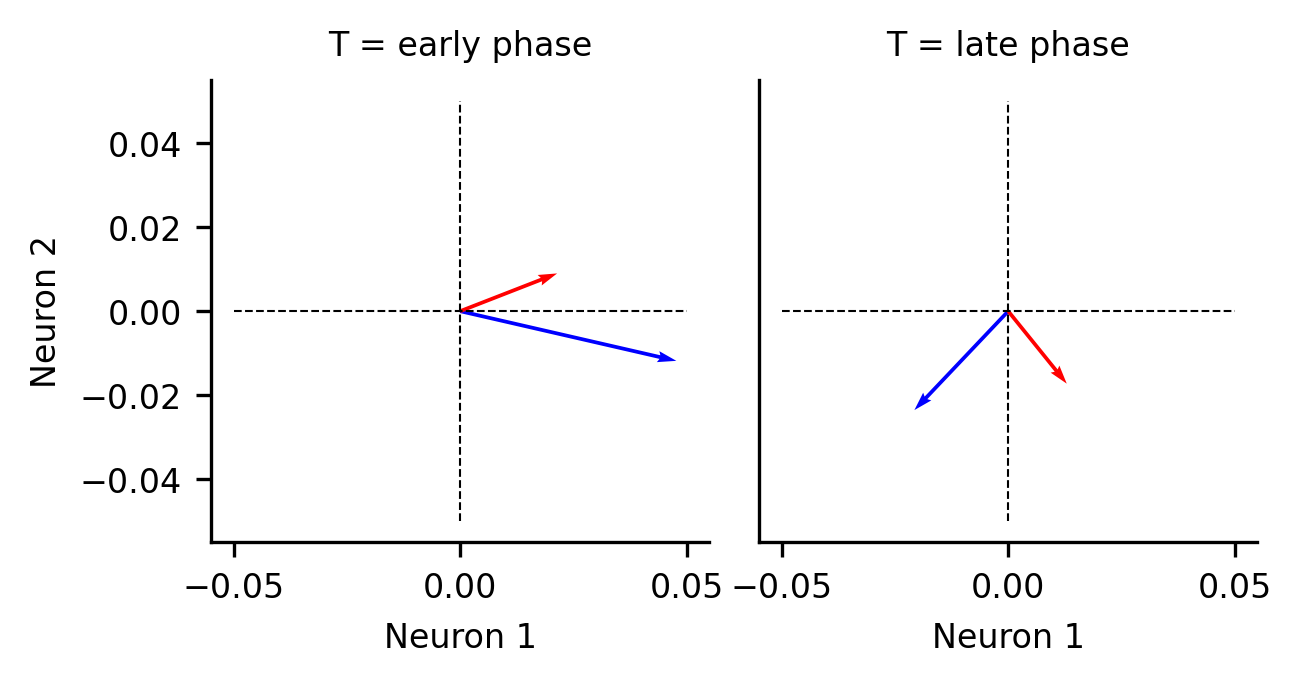

In [18]:
fig, ax = plt.subplots(1,2, figsize = (4.5,2))

t = t0
v_l_v1 = np.array([low_sf_1[t], low_sf_2[t]])
v_h_v1 = np.array([high_sf_1[t], high_sf_2[t]])

scale = 7
ax[0].quiver(
    0,0, 
    *v_l_v1, 
    scale = scale, color = 'blue'
)
ax[0].quiver(
    0,0, 
    *v_h_v1, 
    scale = scale, color = 'red'
)

ax[0].set_xlabel('Neuron 1', fontsize = fontsize)
ax[0].set_ylabel('Neuron 2', fontsize = fontsize)
ax[0].set_title("T = early phase", fontsize = fontsize)

t = t1
v_l_v1 = np.array([low_sf_1[t], low_sf_2[t]])
v_h_v1 = np.array([high_sf_1[t], high_sf_2[t]])

scale = 7
ax[1].quiver(
    0,0, 
    *v_l_v1, 
    scale = scale, color = 'blue'
)
ax[1].quiver(
    0,0, 
    *v_h_v1, 
    scale = scale, color = 'red'
)

for i in range(2):
    
    ax[i].tick_params(labelsize = fontsize)
    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)

    ax[i].plot([0]*250, np.linspace(-0.05, 0.05, 250), '--', color = 'black', linewidth = linewidth)
    ax[i].plot(np.linspace(-0.05, 0.05, 250), [0]*250, '--', color = 'black', linewidth = linewidth)

ax[1].set_xlabel('Neuron 1', fontsize = fontsize)
ax[1].set_yticks([])
ax[1].set_title("T = late phase", fontsize = fontsize)
fig.subplots_adjust(wspace=0.1)

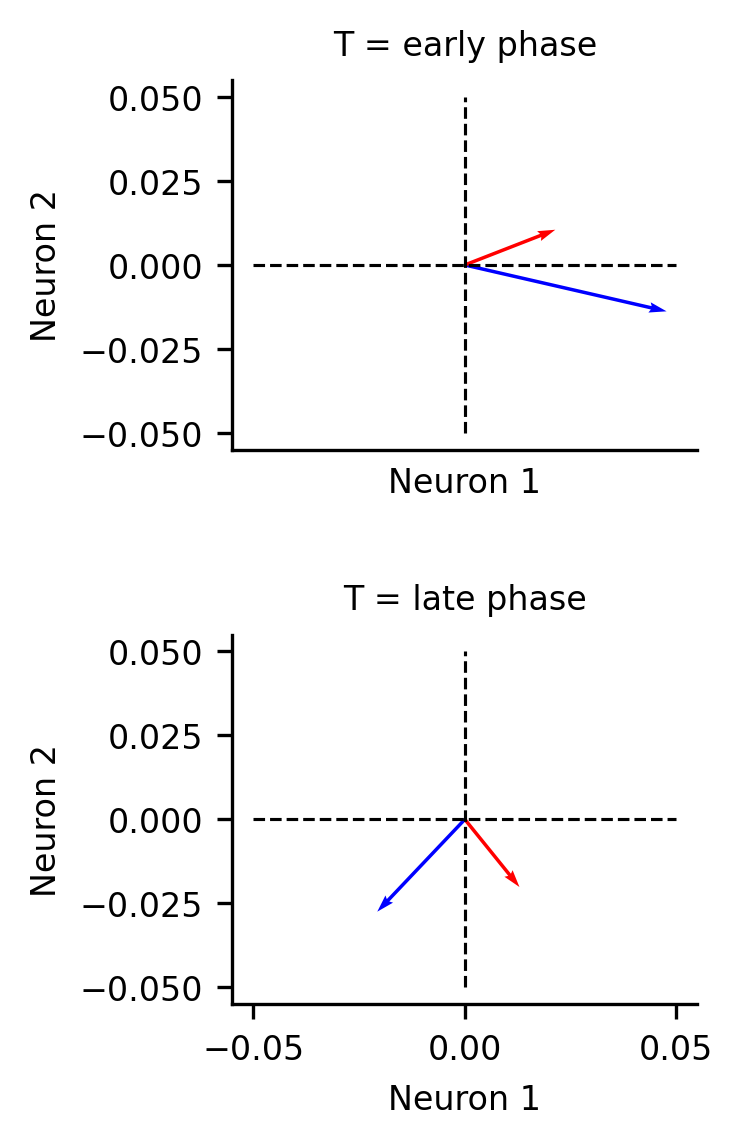

In [37]:
fig, ax = plt.subplots(2,1, figsize = (2, 4))

t = t0
v_l_v1 = np.array([low_sf_1[t], low_sf_2[t]])
v_h_v1 = np.array([high_sf_1[t], high_sf_2[t]])

scale = 7
ax[0].quiver(
    0,0, 
    *v_l_v1, 
    scale = scale, color = 'blue'
)
ax[0].quiver(
    0,0, 
    *v_h_v1, 
    scale = scale, color = 'red'
)

ax[0].set_xlabel('Neuron 1', fontsize = fontsize)
ax[0].set_ylabel('Neuron 2', fontsize = fontsize)
ax[0].set_title("T = early phase", fontsize = fontsize)

t = t1
v_l_v1 = np.array([low_sf_1[t], low_sf_2[t]])
v_h_v1 = np.array([high_sf_1[t], high_sf_2[t]])

scale = 7
ax[1].quiver(
    0,0, 
    *v_l_v1, 
    scale = scale, color = 'blue'
)
ax[1].quiver(
    0,0, 
    *v_h_v1, 
    scale = scale, color = 'red'
)

for i in range(2):
    ax[i].tick_params(labelsize = fontsize)
    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)
    ax[i].plot([0]*250, np.linspace(-0.05, 0.05, 250), '--', color = 'black', linewidth = linewidth)
    ax[i].plot(np.linspace(-0.05, 0.05, 250), [0]*250, '--', color = 'black', linewidth = linewidth)

ax[1].set_xlabel('Neuron 1', fontsize = fontsize)
ax[1].set_ylabel('Neuron 2', fontsize = fontsize)
ax[0].set_xticks([])
ax[1].set_title("T = late phase", fontsize = fontsize)
fig.subplots_adjust(hspace=0.5)

In [20]:
from itertools import combinations
from scipy import stats

In [21]:
def pairwise_vector_correlations(population_resp, sfs):
    sf_combos = list(combinations(sfs, 2)) # list of comparisons of each unique SF condition
    sf_combo_idx = list(combinations(np.arange(len(sfs)),2)) # index wise comparisons of the SF conditions
    sf_octave_diff = np.array([np.log2(x[1]/x[0]) for x in sf_combos]) # octave difference of each SF comparison
    sf_diff_idx = np.argsort(sf_octave_diff) # combo index sorted from lowest to highest octave difference

    corr = np.zeros((sf_diff_idx.shape[0], 250))
    for i, comp in enumerate(sf_combo_idx):
        for t in range(250):
            corr[i, t] = vector_angle(population_resp[comp[0],t,:], 
            population_resp[comp[1],t,:], 'radians')
    corr = corr[sf_diff_idx]

    return corr

In [22]:
resp = predictions[best][:2].numpy().transpose(1,2,0)

In [23]:
corr = pairwise_vector_correlations(resp, X.numpy())

C:\Users\Sturdy\AppData\Local\Temp\ipykernel_30572\1226483008.py:16: RuntimeWarning: invalid value encountered in arccos
  theta = np.arccos(dotab/prodab)


In [24]:
def calculate_sign_sum(X):
    ## Calculate enhancement and suppression sums over time
    nunit, T, nsf = X.shape
    exc_timecourse = np.zeros((T, nsf))
    sup_timecourse = np.zeros((T, nsf))
    for t in range(T):
        for sf in range(nsf):
            exc = X[:,t,sf][X[:,t,sf] > 0].sum()
            sup = X[:,t,sf][X[:,t,sf] < 0].sum()
            exc_timecourse[t,sf] = exc
            sup_timecourse[t,sf] = sup
                
    return exc_timecourse, sup_timecourse

def calculate_esi(exc, sup):
    return (
        (exc - np.abs(sup))
        / (np.abs(sup) + exc)
    ) 

def calculate_desi(esi, return_average = True):
    sf_i = np.arange(0,10)
    comparisons = list(combinations(sf_i, 2))
    
    si_distance = np.zeros((45, 250))

    for i, c in enumerate(comparisons):
        distance = np.abs(esi.T[c[0]] - esi.T[c[1]])
        si_distance[i,:] = distance

    return si_distance

In [25]:
exc, sup = calculate_sign_sum(resp.transpose(2,1,0))

In [26]:
esi = calculate_esi(exc, sup)

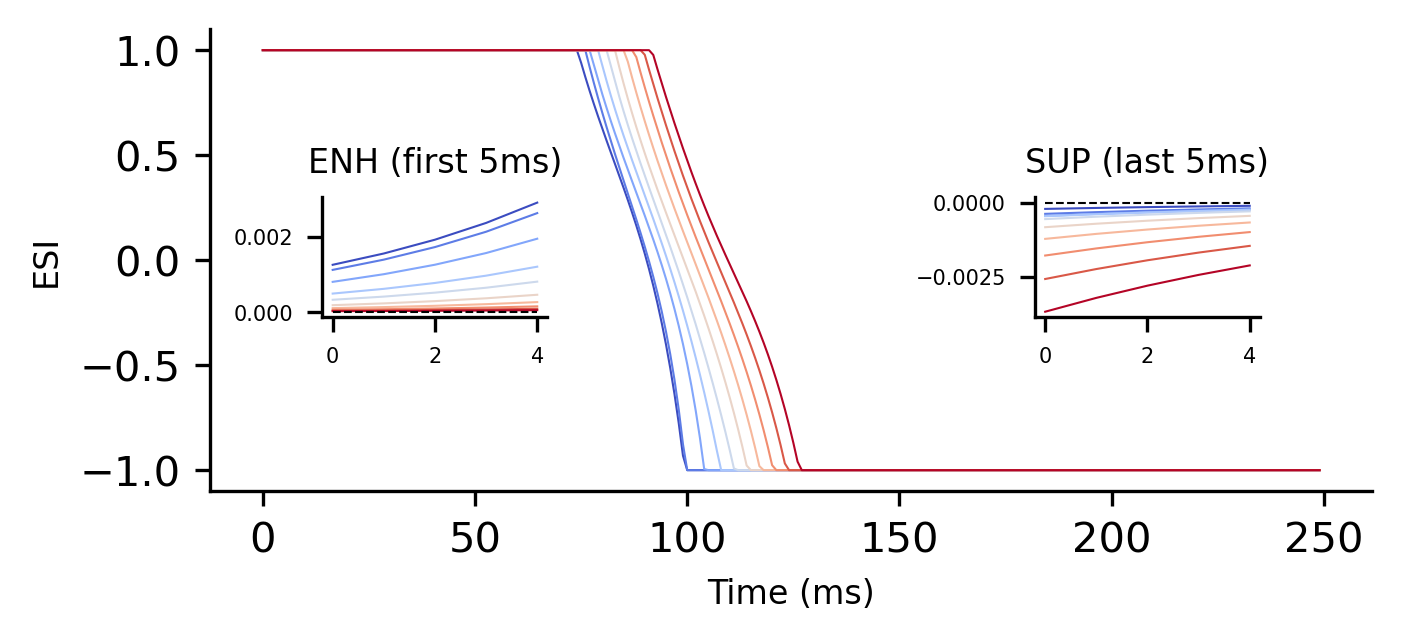

In [27]:
fongsize = 6
cmap = plt.get_cmap('coolwarm') 
rcParams['axes.prop_cycle'] = cycler(color=cmap(np.linspace(0, 1, 10)))
fig, ax = plt.subplots(figsize = (5,2))
ax.plot(esi, linewidth = linewidth)
ax.set_ylabel("ESI", fontsize = fontsize)
ax.set_xlabel("Time (ms)", fontsize = fontsize)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax2 = fig.add_axes([0.2, 0.4, 0.15, 0.2])
ax2.plot(exc[:5], linewidth = linewidth)
ax2.set_title('ENH (first 5ms)', fontsize = fontsize)
ax3 = fig.add_axes([0.675, 0.4, 0.15, 0.2])
ax3.plot(sup[-5:], linewidth = linewidth)
ax3.set_title('SUP (last 5ms)', fontsize = fontsize)

for ax in [ax2, ax3]:
    ax.tick_params(labelsize = 5, rotation = 0)
    #ax.set_ylim(-0.0017,0.0017)
    ax.plot(np.zeros(5), '--', color = 'black', linewidth = linewidth)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

In [28]:
desi = calculate_desi(esi)

In [29]:
sf_combos = list(combinations(X, 2)) # list of comparisons of each unique SF condition
sf_combo_idx = list(combinations(np.arange(len(X)),2)) # index wise comparisons of the SF conditions
sf_octave_diff = np.array([np.log2(x[1]/x[0]) for x in sf_combos]) # octave difference of each SF comparison
sf_diff_idx = np.argsort(sf_octave_diff) # combo index sorted from lowest to highest octave difference
corr[np.where(np.isnan(corr))] = 0

Text(0.5, 1.0, 'SF vector dESI')

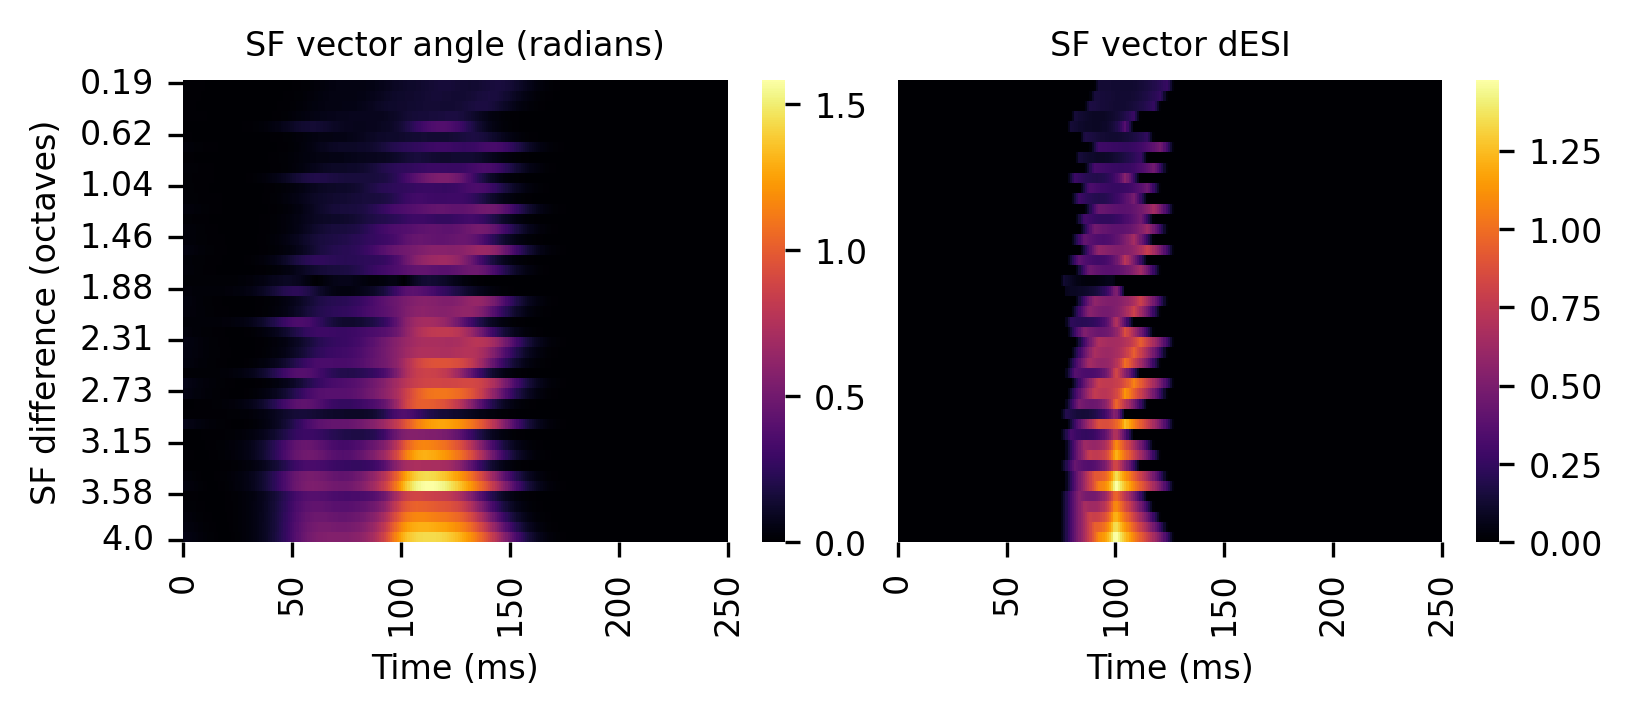

In [30]:
fig, ax = plt.subplots(1,2, figsize = (6, 2))

cmap = 'inferno'
sns.heatmap(
    corr, ax = ax[0], 
    cmap = cmap
)
sns.heatmap(
    desi[sf_diff_idx], ax = ax[1], 
    cmap = cmap
)

for i in range(2):
    ax[i].set_xlabel("Time (ms)", fontsize = fontsize)
    ax[i].tick_params(labelsize = fontsize)
    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)
    ax[i].set_xticks(np.arange(0,300,50))
    ax[i].set_xticklabels(np.arange(0,300,50))
    ax[i].collections[0].colorbar.ax.tick_params(labelsize = fontsize)

plt.subplots_adjust(wspace = 0.05)
ticks = np.arange(0.3,45.5,5)
ticks[-1]-=0.5
ax[0].set_yticks(ticks)
ax[0].set_yticklabels(np.linspace(sf_octave_diff[sf_diff_idx][0], 4, 10).round(2))
ax[0].set_ylabel("SF difference (octaves)", fontsize = fontsize)
ax[1].set_yticks([])
ax[0].set_title("SF vector angle (radians)", fontsize = fontsize)
ax[1].set_title("SF vector dESI", fontsize = fontsize)

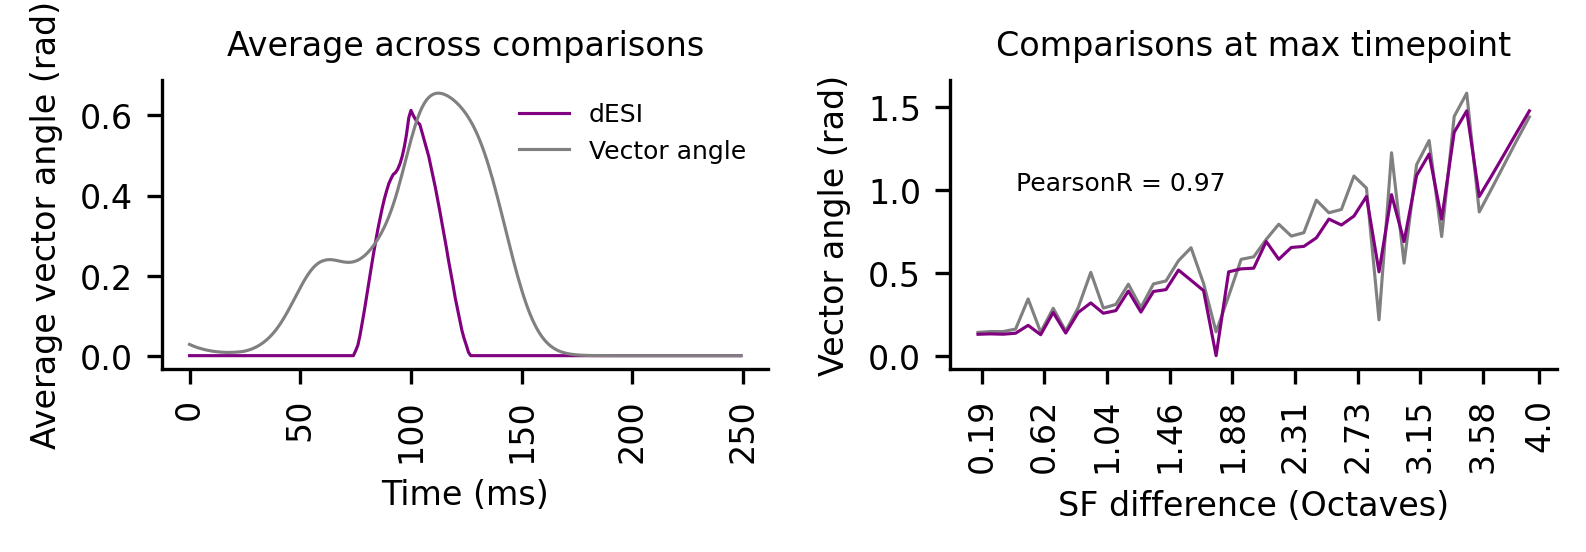

In [31]:
linewidth = 0.75
fig, ax = plt.subplots(1,2, figsize = (6,1.25))
ax[0].plot(desi[sf_diff_idx].mean(0), color = 'purple', label = 'dESI', linewidth = linewidth)
ax[0].plot(corr.mean(0), color = 'gray', label = 'Vector angle', linewidth = linewidth)
ax[0].set_xlabel("Time (ms)", fontsize = fontsize)
ax[0].set_title("Average across comparisons", fontsize = fontsize)
ax[0].set_xticks(np.arange(0,300,50))
ax[0].set_xticklabels(np.arange(0,300,50), rotation = 90)
dmax = np.where(desi[sf_diff_idx].mean(0) == desi[sf_diff_idx].mean(0).max())[0]

pr = stats.pearsonr(corr[:,t1], desi[sf_diff_idx,dmax])[0].round(2)
ax[1].text(3, 1, f"PearsonR = {pr}", fontsize = 6)
ax[1].plot(corr[:,t1], '-', color = 'gray', linewidth = linewidth)
ax[1].plot(desi[sf_diff_idx,dmax], '-', color = 'purple', linewidth = linewidth)
ax[1].set_xticks(np.arange(0,50,5))
ax[1].set_xlabel("SF difference (Octaves)", fontsize = fontsize)
ax[1].set_title("Comparisons at max timepoint", fontsize = fontsize)
ticks = np.arange(0.3,45.5,5)
ticks[-1]-=0.5
ax[1].set_xticks(ticks)
ax[1].set_xticklabels(np.linspace(sf_octave_diff[sf_diff_idx][0], 4, 10).round(2), rotation = 90)

ylabels = ['Average vector angle (rad)', 'Vector angle (rad)']
for i in range(2):
    ax[i].tick_params(labelsize = fontsize)
    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)
    ax[i].set_ylabel(ylabels[i], fontsize = fontsize)

fig.subplots_adjust(wspace=0.3)
ax[0].legend(fontsize = 6, loc = 'upper right', frameon=False)

C:\Users\Sturdy\AppData\Local\Temp\ipykernel_30572\3825258443.py:17: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(desi[sf_diff_idx, dmax][i], corr[i,t1], c=cmap(c_index[c]), s=10)


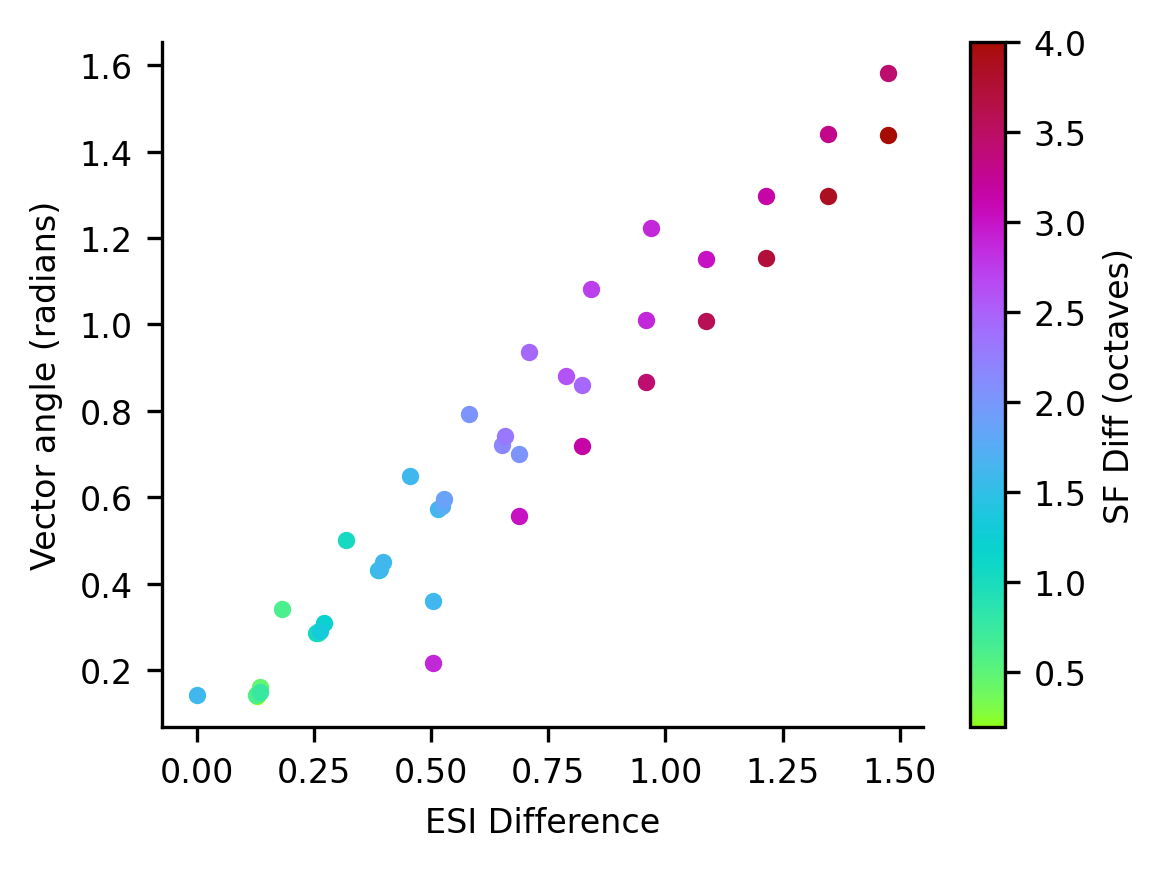

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable


sf_diff_unique = sorted(np.unique(sf_octave_diff))
scales = np.linspace(min(sf_diff_unique), max(sf_diff_unique), 6).round(2)
norm = plt.Normalize(min(sf_diff_unique), max(sf_diff_unique))
cmap = plt.get_cmap('cmr.neon_r')

fig, ax = plt.subplots(figsize=(4, 3))

c_index = np.linspace(0, 1, 28)

for i, diff in enumerate(sf_octave_diff[sf_diff_idx]):
    c = sf_diff_unique.index(diff) 
    ax.scatter(desi[sf_diff_idx, dmax][i], corr[i,t1], c=cmap(c_index[c]), s=10)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(labelsize=fontsize)
ax.set_xlabel("ESI Difference", fontsize=fontsize)
ax.set_ylabel("Vector angle (radians)", fontsize=fontsize)

sm = ScalarMappable(norm=norm, cmap=cmap)
cbar = fig.colorbar(sm, ax=ax)
cbar.ax.tick_params(labelsize=fontsize)
cbar.set_label("SF Diff (octaves)", fontsize=fontsize)

plt.tight_layout()
plt.show()

Text(26.66666666666666, 0.5, 'SF difference (octaves)')

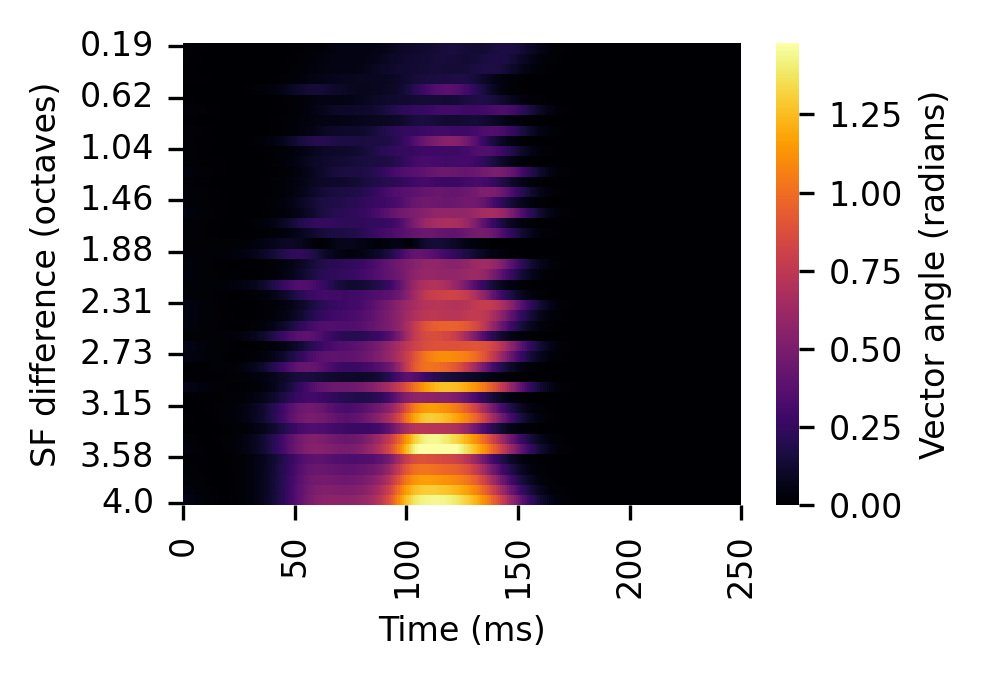

In [33]:
fig, ax = plt.subplots(1, figsize = (3, 2))

cmap = 'inferno'
sns.heatmap(
    corr,
    cmap = cmap,
    vmin = 0, vmax = 1.477
)

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize = fontsize)
cbar.set_label("Vector angle (radians)", fontsize = 8)

ax.set_xlabel("Time (ms)", fontsize = fontsize)
ax.tick_params(labelsize = fontsize)
ax.set_xticks(np.arange(0,300,50))
ax.set_xticklabels(np.arange(0,300,50))
ax.collections[0].colorbar.ax.tick_params(labelsize = fontsize)
ticks = np.arange(0.3,45.5,5)
ticks[-1]-=0.5
ax.set_yticks(ticks)
ax.set_yticklabels(np.linspace(sf_octave_diff[sf_diff_idx][0], 4, 10).round(2))
ax.set_ylabel("SF difference (octaves)", fontsize = fontsize)